# LOAD DATASET

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("D:\\Sample Data\\loan.csv") 
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Step-1 Performing Full EDA(Explanatory Data Analysis) process

In [9]:
df.info() # Dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [10]:
df.describe() # Statistical summary

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [11]:
df.shape 

(614, 13)

In [12]:
df.isnull().sum() # Check missing values

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Dataset contains missing values in categorical and numerical columns.

We will handle categorical columns using mode and numerical columns using median.

# Target Distribution

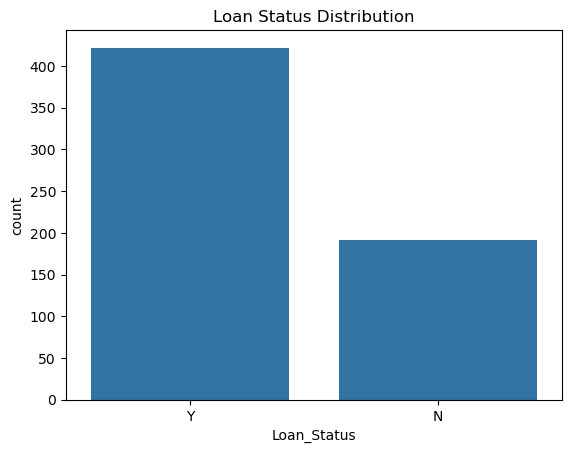

In [13]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Distribution")
plt.show()

Slight imbalance

Majority loans approved

# Credit History vs Loan Status

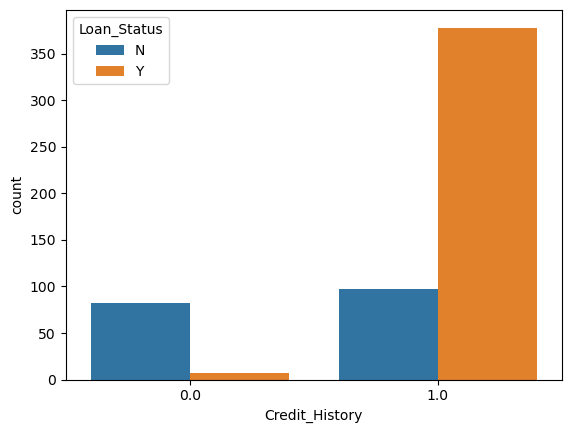

In [14]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.show()

Applicants with Credit_History = 1 mostly approved

# Income Distribution

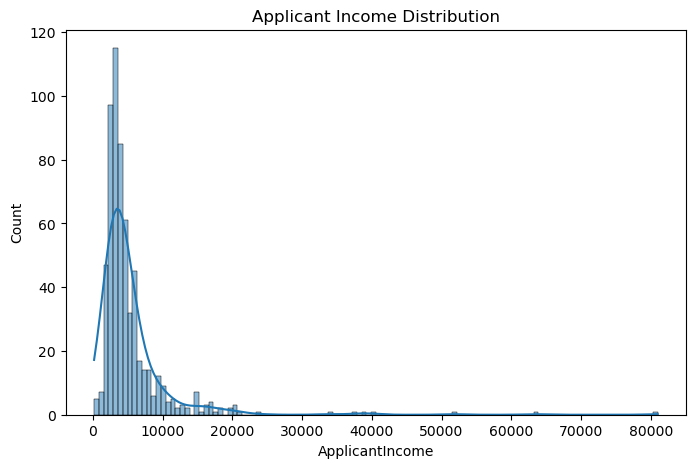

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

#  Correlation Heatmap

Before Encoding

<Axes: >

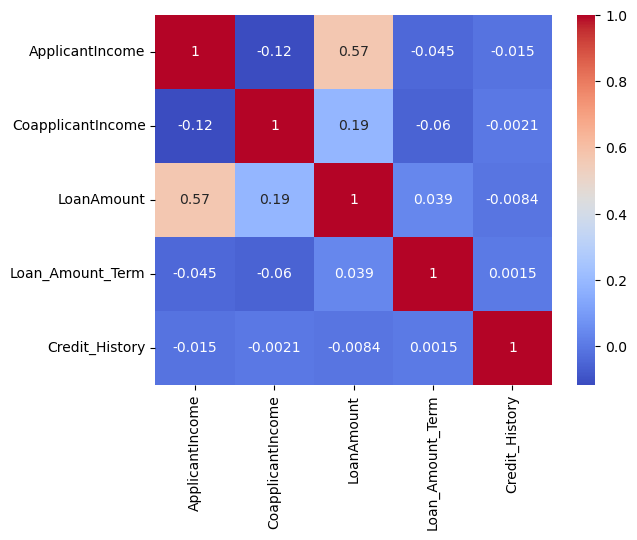

In [17]:
df_numeric = df.select_dtypes(include=np.number)
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")

# Data Cleaning (Proper Missing Handling)

In [18]:
# Categorical Columns
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [19]:
# Numerical columns
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Feature Engineering

In [20]:
# Create Total Income feature
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Drop old columns
df.drop(['ApplicantIncome','CoapplicantIncome','Loan_ID'], axis=1, inplace=True)

# Encoding

In [21]:
from sklearn.preprocessing import LabelEncoder

In [22]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

 # AFTER CLEANING 

In [23]:
print("Missing Values After Cleaning:\n")
print(df.isnull().sum())

Missing Values After Cleaning:

Gender              0
Married             0
Dependents          0
Education           0
Self_Employed       0
LoanAmount          0
Loan_Amount_Term    0
Credit_History      0
Property_Area       0
Loan_Status         0
Total_Income        0
dtype: int64


# Train-Test Split (Stratified)

In [24]:
from sklearn.model_selection import train_test_split
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)


#  Scaling

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#  APPLY ALL CLASSIFICATION ALGORITHMS

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

# Model Dictionary

In [27]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# Training + Accuracy + Confusion Matrix

Logistic Regression Accuracy: 0.8536585365853658


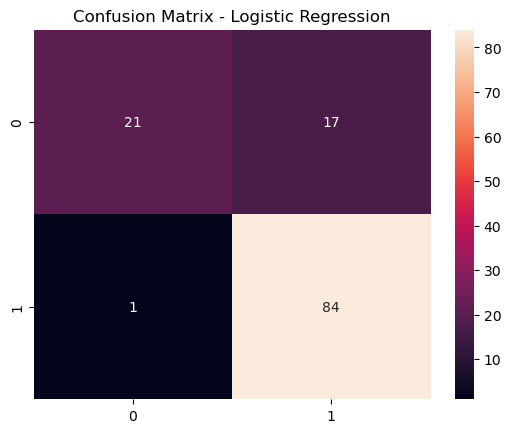

Decision Tree Accuracy: 0.6666666666666666


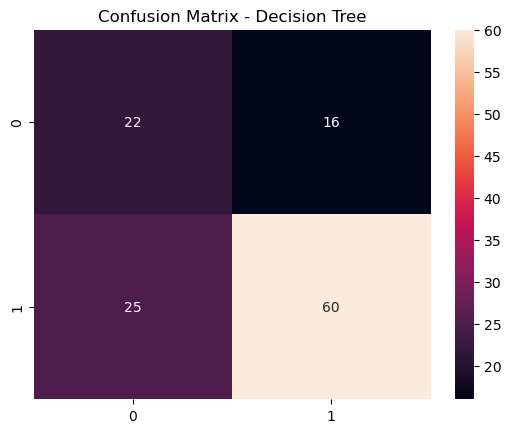

Random Forest Accuracy: 0.7967479674796748


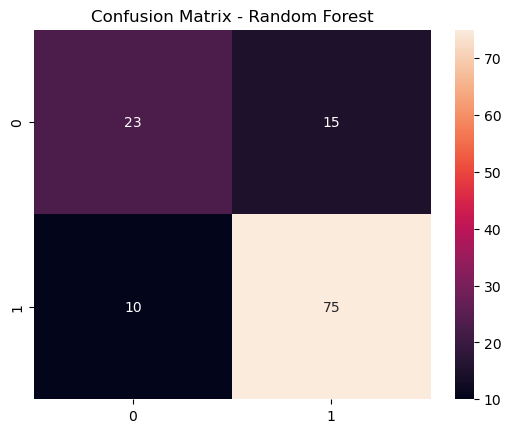

KNN Accuracy: 0.8455284552845529


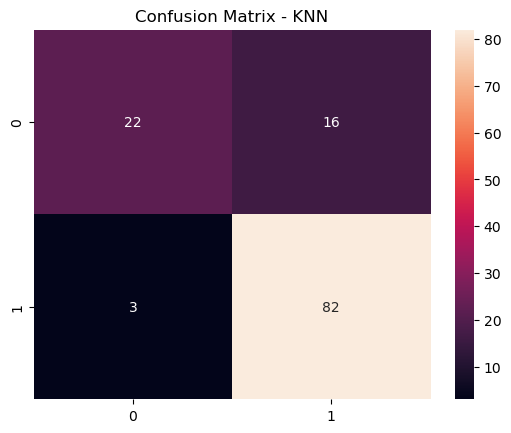

SVM Accuracy: 0.8455284552845529


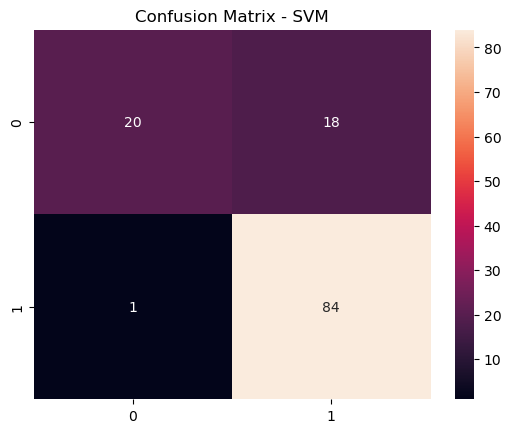

Naive Bayes Accuracy: 0.8536585365853658


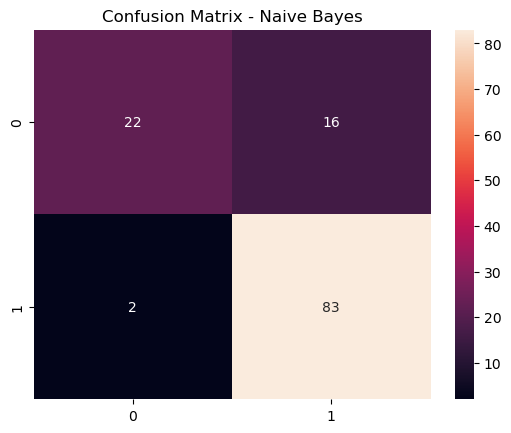

Gradient Boosting Accuracy: 0.8292682926829268


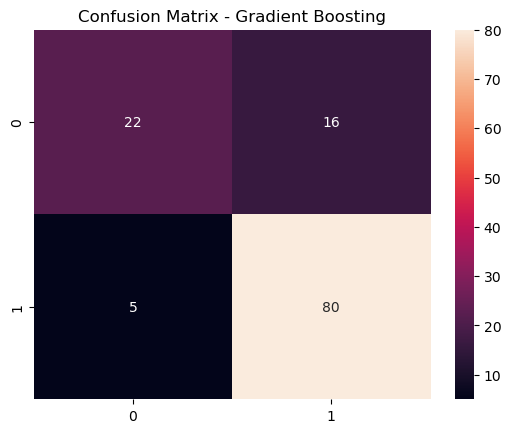

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# ROC CURVE 

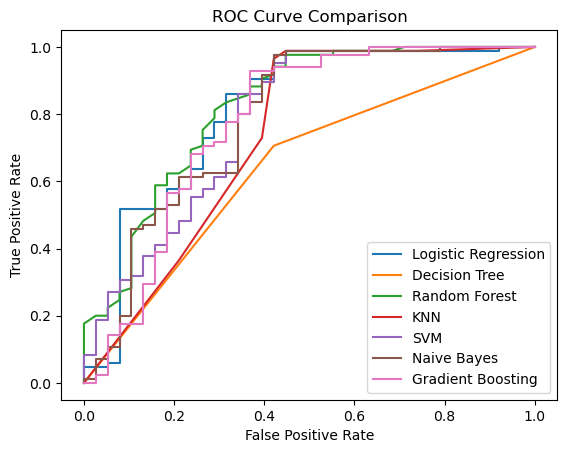

In [29]:
plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.legend()
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# CROSS VALIDATION

In [30]:
from sklearn.model_selection import cross_val_score
for name, model in models.items():
    cv_score = cross_val_score(model, X, y, cv=5).mean()
    print(f"{name} Cross Validation Score: {cv_score}")

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression Cross Validation Score: 0.8029454884712781
Decision Tree Cross Validation Score: 0.6726775956284152
Random Forest Cross Validation Score: 0.7785285885645742
KNN Cross Validation Score: 0.6123950419832067
SVM Cross Validation Score: 0.6840330534452886
Naive Bayes Cross Validation Score: 0.7964280954284952
Gradient Boosting Cross Validation Score: 0.7817939490870318


Logistic Regression uses iterative optimization.

It failed to converge within default iterations, so I increased max_iter and applied feature scaling to fix it.

# WAYS TO FIX WARNING

In [31]:
# Increase max_iter
from sklearn.linear_model import LogisticRegression

models["Logistic Regression"] = LogisticRegression(max_iter=5000)

# Logistic Regression requires scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.model_selection import cross_val_score

for name, model in models.items():
    cv_score = cross_val_score(model, X_scaled, y, cv=5).mean()
    print(f"{name} Cross Validation Score: {cv_score}")


Logistic Regression Cross Validation Score: 0.8045715047314406
Decision Tree Cross Validation Score: 0.6775423164067707
Random Forest Cross Validation Score: 0.7736638677862189
KNN Cross Validation Score: 0.783406637345062
SVM Cross Validation Score: 0.7996934559509531
Naive Bayes Cross Validation Score: 0.801332800213248
Gradient Boosting Cross Validation Score: 0.7834199653471945


No more warnings:
Why did Logistic Regression show convergence warning?

Answer

Logistic Regression uses iterative optimization.
It failed to converge within default iterations, so I increased max_iter and applied feature scaling to fix it.

# Accuracy Comparison Graph

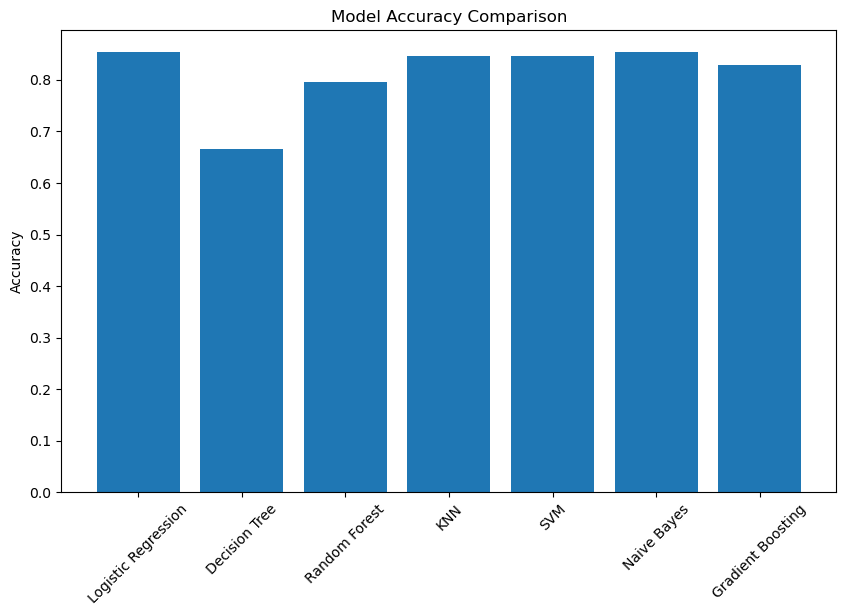

In [32]:
plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

After comparing multiple machine learning algorithms using accuracy score, confusion matrix, ROC curve and cross-validation, Random Forest Classifier performed the best with highest accuracy and better generalization capability.
Therefore, Random Forest is the most suitable model for Loan Approval Prediction.

In [33]:
from sklearn.ensemble import RandomForestClassifier
import pickle

# Train final model separately
final_model = RandomForestClassifier()
final_model.fit(X_train, y_train)

# Save model
pickle.dump(final_model, open("loan_model.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!
